# Behavioural economics and Eurovision

 

Here it is analysed country performance and voting patterns in the 
Eurovision Song Competition. This is a competition held annually since 1956 
(except for 2020) among countries which are members of the European 
Broadcasting Union (or those invited to participate as guests). Each competing 
country enters a song. The winning song is determined by countries voting to award 
points to other countries (countries cannot vote for themselves); the country which 
winds up with the most total points wins the competition.

Our initial step was to import pandas, which is our primary library to work with data on python.

This will be followed by obtaining our data sets through their respective URL's. One for the "contestants" and another for the "votes".

In [1]:
import pandas as pd

In [2]:
contestants = pd.read_csv('https://raw.githubusercontent.com/tturocy/eco7026a/main/2022-23/contestants.csv')
contestants

,year,to_country_id,to_country,performer,song,place_contest,sf_num,running_final,running_sf,place_final,...,place_sf,points_sf,points_tele_final,points_jury_final,points_tele_sf,points_jury_sf,composers,lyricists,lyrics,youtube_url
0,1956,ch,Switzerland,Lys Assia,Refrain,2.0,NaN,2.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Georg Benz Stahl,NaN,"(Refrain d'amour...)\n\nRefrain, couleur du ci...",https://youtube.com/watch?v=IyqIPvOkiRk
1,1956,nl,Netherlands,Jetty Paerl,De Vogels Van Holland,2.0,NaN,1.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Cor Lemaire,Annie M. G. Schmidt,De vogels van Holland zijn zo muzikaal\nZe ler...,https://youtube.com/watch?v=u45UQVGRVPA
2,1956,be,Belgium,Fud Leclerc,Messieurs Les Noyés De La Seine,2.0,NaN,3.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Jacques Say;Jean Miret,Robert Montal,Messieurs les noyés de la Seine\nOuvrez-moi le...,https://youtube.com/watch?v=U9O3sqlyra0
3,1956,de,Germany,Walter Andreas Schwarz,Im Wartesaal Zum Großen Glück,2.0,NaN,4.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Walter Andreas Schwarz,NaN,"Es gibt einen Hafen, da fährt kaum ein Schiff\...",https://youtube.com/watch?v=BDNARIDnmTc
4,1956,fr,France,Mathé Altéry,Le Temps Perdu,2.0,NaN,5.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,André Lodge,Rachèle Thoreau,"Chante, carillon\nLe chant du temps perdu\nCha...",https://youtube.com/watch?v=dm1L0XyikKI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1729,2023,lv,Latvia,Sudden Lights,Aijā,NaN,1.0,NaN,4.0,NaN,...,11.0,34.0,NaN,NaN,NaN,NaN,Andrejs Reinis Zitmanis;Kārlis Matīss Zitmanis...,Andrejs Reinis Zitmanis,Aijā\n\nYou said some words didn't hear you fa...,https://youtube.com/watch?v=xAjVA3qwqGk
1730,2023,ie,Ireland,Wild Youth,We Are One,NaN,1.0,NaN,6.0,NaN,...,12.0,10.0,NaN,NaN,NaN,NaN,Conor O'Donohoe;Edward Porter;Jörgen Elofsson,NaN,We Are One\n\nWe take our first breath\nAnd th...,https://youtube.com/watch?v=ak5Fevs424Y
1731,2023,nl,Netherlands,Mia Nicolai & Dion Cooper,Burning Daylight,NaN,1.0,NaN,14.0,NaN,...,13.0,7.0,NaN,NaN,NaN,NaN,Dion Cooper;Duncan Laurence;Jordan Garfield;Lo...,NaN,Burning Daylight\n\nI don't find any joy anymo...,https://youtube.com/watch?v=UOf-oKDlO6A
1732,2023,az,Azerbaijan,TuralTuranX,Tell Me More,NaN,1.0,NaN,12.0,NaN,...,14.0,4.0,NaN,NaN,NaN,NaN,Nihad Aliyev;Tunar Tağiyev;Tural Bağmanov;Tura...,Tural Bağmanov;Turan Bağmanov,Tell Me More\n\nYour call has been forwarded t...,https://youtube.com/watch?v=5dvsr-L3HgY


In [3]:
contestants.dtypes

year                   int64
to_country_id         object
to_country            object
performer             object
song                  object
place_contest        float64
sf_num               float64
running_final        float64
running_sf           float64
place_final          float64
points_final         float64
place_sf             float64
points_sf            float64
points_tele_final    float64
points_jury_final    float64
points_tele_sf       float64
points_jury_sf       float64
composers             object
lyricists             object
lyrics                object
youtube_url           object
dtype: object

As we can see the contestants data set has a lot of columns. Some of those which will not be used entirely for our analysis. So we can start cleaning our data, by leaving just the columns with the most relevant data.

Between the information we are substarcting are all the columns about the performer, the composer, the video of the song, and how they did during the semi finals, because for this analysis will be solely focusing in the final round.


In [4]:
contestants2 = contestants[['year', 'to_country_id','to_country', 'place_contest', 'running_final', 'place_final', 'points_final', 'points_tele_final', 'points_jury_final']]
contestants2

,year,to_country_id,to_country,place_contest,running_final,place_final,points_final,points_tele_final,points_jury_final
0,1956,ch,Switzerland,2.0,2.0,2.0,NaN,NaN,NaN
1,1956,nl,Netherlands,2.0,1.0,2.0,NaN,NaN,NaN
2,1956,be,Belgium,2.0,3.0,2.0,NaN,NaN,NaN
3,1956,de,Germany,2.0,4.0,2.0,NaN,NaN,NaN
4,1956,fr,France,2.0,5.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1729,2023,lv,Latvia,NaN,NaN,NaN,NaN,NaN,NaN
1730,2023,ie,Ireland,NaN,NaN,NaN,NaN,NaN,NaN
1731,2023,nl,Netherlands,NaN,NaN,NaN,NaN,NaN,NaN
1732,2023,az,Azerbaijan,NaN,NaN,NaN,NaN,NaN,NaN


Now we open the "votes" data base, which shows us how the countries voted and received votes.

In [5]:
votes = pd.read_csv('https://raw.githubusercontent.com/tturocy/eco7026a/main/2022-23/votes.csv')
votes

,year,round,from_country_id,to_country_id,from_country,to_country,total_points,tele_points,jury_points
0,1957,final,at,nl,at,nl,6,NaN,NaN
1,1957,final,at,fr,at,fr,0,NaN,NaN
2,1957,final,at,dk,at,dk,0,NaN,NaN
3,1957,final,at,lu,at,lu,3,NaN,NaN
4,1957,final,at,de,at,de,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51349,2023,final,wld,al,wld,al,6,6.0,NaN
51350,2023,final,wld,pt,wld,pt,0,0.0,NaN
51351,2023,final,wld,rs,wld,rs,0,0.0,NaN
51352,2023,final,wld,gb,wld,gb,0,0.0,NaN


As for the voting column we can do an initial substracion of data, by substracting the lines that are not about the final round. Since this are the points we want to focus on.

In [6]:
votes2 = votes[votes['round']=='final']
votes2

,year,round,from_country_id,to_country_id,from_country,to_country,total_points,tele_points,jury_points
0,1957,final,at,nl,at,nl,6,NaN,NaN
1,1957,final,at,fr,at,fr,0,NaN,NaN
2,1957,final,at,dk,at,dk,0,NaN,NaN
3,1957,final,at,lu,at,lu,3,NaN,NaN
4,1957,final,at,de,at,de,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51349,2023,final,wld,al,wld,al,6,6.0,NaN
51350,2023,final,wld,pt,wld,pt,0,0.0,NaN
51351,2023,final,wld,rs,wld,rs,0,0.0,NaN
51352,2023,final,wld,gb,wld,gb,0,0.0,NaN


One major change in the structure of the contest was the pointing system. With the current system each country can just give points to 10 countries and the value of the points can be 12, 10 and from 8 to 1.

To perform our analysis we want to focus just in the years since this ponting system was stablished.

In [7]:
votes3 = votes2.groupby(['year', 'from_country']).sum('total_points')
votes3

total_points  tele_points  jury_points
year from_country                                        
1957 at                      10          0.0          0.0
     be                      10          0.0          0.0
     ch                      10          0.0          0.0
     de                      10          0.0          0.0
     dk                      10          0.0          0.0
...                         ...          ...          ...
2023 se                     116         58.0         58.0
     si                     116         58.0         58.0
     sm                     116         58.0         58.0
     ua                     116         58.0         58.0
     wld                     58         58.0          0.0

[1668 rows x 3 columns]

In [8]:
votes3['total_points'].unique()

array([ 10,   6,  15,   9,  76,  80,  83,  71,  78, 107,  98,  95,  72,
        43, 100,  75,  86,  91,  73,  92,  89,  85,  87, 106,  99,  74,
        88, 105,  93,  97,  94,  82,  68,  77, 103,  58, 116], dtype=int64)

With the new rules the total amount of points countries and judges can assign is "58" or "116" with the ones assigned by the judges.

In [9]:
votes4= votes3[(votes3['total_points']== 58) | (votes3['total_points']== 116)]
votes4

total_points  tele_points  jury_points
year from_country                                        
1975 be                      58          0.0          0.0
     ch                      58          0.0          0.0
     de                      58          0.0          0.0
     es                      58          0.0          0.0
     fi                      58          0.0          0.0
...                         ...          ...          ...
2023 se                     116         58.0         58.0
     si                     116         58.0         58.0
     sm                     116         58.0         58.0
     ua                     116         58.0         58.0
     wld                     58         58.0          0.0

[1392 rows x 3 columns]

In [10]:
votes5 = votes4.reset_index(['year', 'from_country'])
votes5

,year,from_country,total_points,tele_points,jury_points
0,1975,be,58,0.0,0.0
1,1975,ch,58,0.0,0.0
2,1975,de,58,0.0,0.0
3,1975,es,58,0.0,0.0
4,1975,fi,58,0.0,0.0
...,...,...,...,...,...
1387,2023,se,116,58.0,58.0
1388,2023,si,116,58.0,58.0
1389,2023,sm,116,58.0,58.0
1390,2023,ua,116,58.0,58.0


Now we have our filtered "votes" data base. This is the information we will use for further analysis.

In [11]:
nps=votes5['year'].min()
nps

1975

nps = new points system

Now that we have the first year when the new system started we can take that into consideration for the contestants data base.
Here we will count from the first year of the new system to the present and we will also eliminated the data from the year 2020, since that year the contest couldn't be held properly due to the Covid-19 pandemic.

In [12]:
contestants3 = contestants2[(contestants2['year']>= nps) & (contestants2['year']!=2020) & (contestants2['place_final']>=1)]
contestants3

,year,to_country_id,to_country,place_contest,running_final,place_final,points_final,points_tele_final,points_jury_final
288,1975,nl,Netherlands,1.0,1.0,1.0,152.0,NaN,NaN
289,1975,gb,United Kingdom,2.0,9.0,2.0,138.0,NaN,NaN
290,1975,it,Italy,3.0,19.0,3.0,115.0,NaN,NaN
291,1975,fr,France,4.0,3.0,4.0,91.0,NaN,NaN
292,1975,lu,Luxembourg,5.0,5.0,5.0,84.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1703,2023,al,Albania,22.0,10.0,22.0,76.0,59.0,17.0
1704,2023,pt,Portugal,23.0,2.0,23.0,59.0,16.0,43.0
1705,2023,rs,Serbia,24.0,5.0,24.0,30.0,16.0,14.0
1706,2023,gb,United Kingdom,25.0,26.0,25.0,24.0,9.0,15.0


1. Now that we have cleaner data sets, we can proceed with our analysis, starting with the consistency of the data, meaning that the points awarded in the "contestants" is the same as the ones given in the "votes" data set.

In [13]:
c3 = contestants3.groupby('year').sum('points_final')
c3

,place_contest,running_final,place_final,points_final,points_tele_final,points_jury_final
year,,,,,,
1975,189.0,190.0,189.0,1102.0,0.0,0.0
1976,171.0,171.0,171.0,1044.0,0.0,0.0
1977,170.0,171.0,170.0,1044.0,0.0,0.0
1978,208.0,210.0,208.0,1160.0,0.0,0.0
1979,189.0,190.0,189.0,1102.0,0.0,0.0
1980,190.0,190.0,190.0,1102.0,0.0,0.0
1981,208.0,210.0,208.0,1160.0,0.0,0.0
1982,171.0,171.0,171.0,1044.0,0.0,0.0
1983,207.0,210.0,207.0,1160.0,0.0,0.0


In [14]:
v2= votes2.groupby('year').sum('total_points')
v2

,total_points,tele_points,jury_points
year,,,
1957,100,0.0,0.0
1958,100,0.0,0.0
1959,110,0.0,0.0
1960,130,0.0,0.0
1961,160,0.0,0.0
...,...,...,...
2018,4988,2494.0,2494.0
2019,4756,2378.0,2378.0
2021,4524,2262.0,2262.0


Now we a similar metric for "contestants" and "votes", which is the total amount of points given per year, we can use this to check the consistency of our data. here we want to compare the total points of each year, with the assumption that the have to be the same.

In [15]:
c3v2 = c3.merge(v2, on='year')
c3v2

,place_contest,running_final,place_final,points_final,points_tele_final,points_jury_final,total_points,tele_points,jury_points
year,,,,,,,,,
1975,189.0,190.0,189.0,1102.0,0.0,0.0,1102,0.0,0.0
1976,171.0,171.0,171.0,1044.0,0.0,0.0,1044,0.0,0.0
1977,170.0,171.0,170.0,1044.0,0.0,0.0,1044,0.0,0.0
1978,208.0,210.0,208.0,1160.0,0.0,0.0,1160,0.0,0.0
1979,189.0,190.0,189.0,1102.0,0.0,0.0,1102,0.0,0.0
1980,190.0,190.0,190.0,1102.0,0.0,0.0,1102,0.0,0.0
1981,208.0,210.0,208.0,1160.0,0.0,0.0,1160,0.0,0.0
1982,171.0,171.0,171.0,1044.0,0.0,0.0,1044,0.0,0.0
1983,207.0,210.0,207.0,1160.0,0.0,0.0,1160,0.0,0.0


In [16]:
residuals = c3v2.assign(residuals = c3v2['points_final'] - c3v2['total_points'])
residuals[['points_final', 'total_points', 'residuals']]

,points_final,total_points,residuals
year,,,
1975,1102.0,1102,0.0
1976,1044.0,1044,0.0
1977,1044.0,1044,0.0
1978,1160.0,1160,0.0
1979,1102.0,1102,0.0
1980,1102.0,1102,0.0
1981,1160.0,1160,0.0
1982,1044.0,1044,0.0
1983,1160.0,1160,0.0


In [17]:
residuals['residuals'].sum()

0.0

After making the substraction of the columns and adding this numbers, we can appreciate that as we expected the total points in both data sets is the same, since the substraction of the values of each year is equal to zero.

In [18]:
contestants3.groupby(['place_final', 'year']).sum('points_final')

place_contest  running_final  points_final  \
place_final year                                               
1.0         1975            1.0            1.0         152.0   
            1976            1.0            1.0         164.0   
            1977            1.0           18.0         136.0   
            1978            1.0           18.0         157.0   
            1979            1.0           10.0         125.0   
...                         ...            ...           ...   
26.0        2018           26.0            8.0          39.0   
            2019           26.0           16.0          11.0   
            2021           26.0            9.0           0.0   
            2023           26.0           21.0          18.0   
27.0        2015           27.0           17.0           0.0   

                  points_tele_final  points_jury_final  
place_final year                                        
1.0         1975                0.0                0.0  
            1976                0.0                0.0  
            1977                0.0                0.0  
            1978                0.0                0.0  
            1979                0.0                0.0  
...                             ...                ...  
26.0        2018               18.0               21.0  
            2019                3.0                8.0  
            2021                0.0                0.0  
            2023               15.0                3.0  
27.0        2015                0.0                0.0  

[1059 rows x 5 columns]

2. The next part of our analysis is to determine which countries have been the most and least succesful in the history of the contest. Is important to mentioned that the number of participants per year and through the history of the contest, therefore as an initial part of our analysis we will count how many times have each country been on the contest.

In [19]:
contestants3['to_country'].value_counts()

United Kingdom          48
Spain                   48
France                  47
Germany                 47
Sweden                  46
Norway                  44
Greece                  39
Israel                  36
Belgium                 35
Finland                 35
Ireland                 35
Portugal                35
Denmark                 34
Austria                 34
Netherlands             34
Turkey                  33
Switzerland             33
Cyprus                  32
Italy                   29
Iceland                 27
Malta                   24
Russia                  22
Luxembourg              19
Romania                 19
Croatia                 19
Ukraine                 18
Estonia                 18
Bosnia & Herzegovina    18
Poland                  16
Lithuania               16
Slovenia                16
Hungary                 14
Azerbaijan              13
Yugoslavia              13
Moldova                 13
Armenia                 12
Serbia                  12
A

In this list we can appreciate countries that have been part of the contest since the first year we analyze to the current. Also some guests that have had less times participating. Also as is well known European history has seen a lot of socio-political changes in the last century, some of these can be reflected in certain countries that appear on the list, such as Yugoslavia, which separated into different countries. 

Another aspect to be consider here is the use of different names for similar territories, particularly for North Macedonia and the Czech Republic, which appear with different names, given us back incorrect numbers, so we have to modify this.

In [20]:
contestants3 = contestants3.assign(to_country = contestants3['to_country'].replace({
  'North MacedoniaN.Macedonia' : 'North Macedonia',
    'Czechia':'Czech Republic'
}))
contestants3['to_country'].value_counts()

Spain                   48
United Kingdom          48
France                  47
Germany                 47
Sweden                  46
Norway                  44
Greece                  39
Israel                  36
Portugal                35
Finland                 35
Ireland                 35
Belgium                 35
Netherlands             34
Austria                 34
Denmark                 34
Switzerland             33
Turkey                  33
Cyprus                  32
Italy                   29
Iceland                 27
Malta                   24
Russia                  22
Romania                 19
Croatia                 19
Luxembourg              19
Ukraine                 18
Estonia                 18
Bosnia & Herzegovina    18
Slovenia                16
Poland                  16
Lithuania               16
Hungary                 14
Yugoslavia              13
Azerbaijan              13
Moldova                 13
Armenia                 12
Serbia                  12
A

Now we have the correct numbers, to proceed forward with our analysis.

In [21]:
firstp=contestants3[contestants3['place_contest']==1]
firstp

,year,to_country_id,to_country,place_contest,running_final,place_final,points_final,points_tele_final,points_jury_final
288,1975,nl,Netherlands,1.0,1.0,1.0,152.0,NaN,NaN
307,1976,gb,United Kingdom,1.0,1.0,1.0,164.0,NaN,NaN
325,1977,fr,France,1.0,18.0,1.0,136.0,NaN,NaN
343,1978,il,Israel,1.0,18.0,1.0,157.0,NaN,NaN
363,1979,il,Israel,1.0,10.0,1.0,125.0,NaN,NaN
382,1980,ie,Ireland,1.0,17.0,1.0,143.0,NaN,NaN
401,1981,gb,United Kingdom,1.0,14.0,1.0,136.0,NaN,NaN
421,1982,de,Germany,1.0,18.0,1.0,161.0,NaN,NaN
439,1983,lu,Luxembourg,1.0,20.0,1.0,142.0,NaN,NaN
459,1984,se,Sweden,1.0,1.0,1.0,145.0,NaN,NaN


In [22]:
firstp['to_country'].value_counts()

Ireland           6
Sweden            6
Israel            4
Norway            3
Ukraine           3
United Kingdom    3
Netherlands       2
Denmark           2
Italy             2
Germany           2
Belgium           1
Switzerland       1
Yugoslavia        1
Luxembourg        1
Estonia           1
Latvia            1
Turkey            1
France            1
Greece            1
Finland           1
Serbia            1
Russia            1
Azerbaijan        1
Austria           1
Portugal          1
Name: to_country, dtype: int64

Here we have a list of all the winners of the contest since the year 1975. Even though winning is the main goal of the contest we cannot limit our conclusion of these as the sole meetric of performance in the history of the contetst, since there have been countries who have had more chances to participate and this is something we also need to take into account.

In [23]:
contestants_place = contestants3.groupby('to_country')[['place_contest', 'year']].agg(['min', 'max', 'mean'])
stats = contestants_place.assign(participation=contestants3['to_country'].value_counts())
stats.sort_values(('place_contest','mean'))

place_contest                   year                     \
                               min   max       mean   min   max         mean   
to_country                                                                     
Serbia & Montenegro            2.0   7.0   4.500000  2004  2005  2004.500000   
Bulgaria                       2.0  14.0   7.200000  2007  2021  2015.800000   
Italy                          1.0  21.0   7.344828  1975  2023  1998.103448   
Russia                         1.0  17.0   7.681818  1994  2021  2007.363636   
Monaco                         3.0  16.0   8.000000  1975  1979  1977.000000   
Ukraine                        1.0  24.0   8.277778  2003  2023  2012.166667   
Sweden                         1.0  22.0   8.456522  1975  2023  1998.804348   
Ireland                        1.0  26.0   9.485714  1975  2018  1993.628571   
Australia                      2.0  20.0   9.857143  2015  2023  2018.571429   
Azerbaijan                     1.0  22.0  10.153846  2008  2022  2014.384615   
Israel                         1.0  24.0  10.611111  1975  2023  1997.138889   
Denmark                        1.0  24.0  10.823529  1978  2019  1997.176471   
Estonia                        1.0  24.0  10.888889  1994  2023  2007.333333   
Yugoslavia                     1.0  21.0  11.076923  1975  1992  1984.923077   
Armenia                        4.0  20.0  11.166667  2006  2023  2013.333333   
Malta                          2.0  25.0  11.250000  1975  2021  2002.291667   
Netherlands                    1.0  23.0  11.264706  1975  2022  1995.647059   
Greece                         1.0  21.0  11.307692  1976  2022  1998.666667   
Latvia                         1.0  24.0  11.600000  2000  2016  2006.300000   
Luxembourg                     1.0  21.0  11.631579  1975  1993  1984.000000   
Switzerland                    1.0  25.0  11.696970  1975  2023  1994.060606   
United Kingdom                 1.0  26.0  11.875000  1975  2023  1998.562500   
Moldova                        3.0  22.0  12.076923  2005  2023  2013.384615   
France                         1.0  26.0  12.106383  1975  2023  1998.914894   
Norway                         1.0  26.0  12.159091  1975  2023  1997.613636   
Serbia                         1.0  24.0  12.166667  2007  2023  2015.166667   
Croatia                        4.0  23.0  12.368421  1993  2023  2003.473684   
Georgia                        9.0  20.0  12.428571  2007  2016  2011.428571   
Turkey                         1.0  22.0  12.636364  1975  2012  1994.424242   
Belgium                        1.0  25.0  12.685714  1975  2023  1995.142857   
Bosnia & Herzegovina           3.0  22.0  13.166667  1993  2012  2002.888889   
Germany                        1.0  27.0  13.234043  1975  2023  1998.617021   
Romania                        3.0  22.0  13.315789  1994  2022  2007.894737   
Cyprus                         2.0  22.0  13.437500  1981  2023  1999.593750   
Austria                        1.0  26.0  13.735294  1976  2023  1994.852941   
Iceland                        2.0  23.0  13.925926  1986  2022  2001.629630   
Spain                          2.0  26.0  14.062500  1975  2023  1998.562500   
North Macedonia                7.0  19.0  14.444444  1998  2019  2005.888889   
Portugal                       1.0  26.0  14.771429  1975  2023  1994.485714   
Czech Republic                 6.0  25.0  14.800000  2016  2023  2019.600000   
Hungary                        4.0  24.0  15.071429  1994  2018  2008.000000   
Albania                        5.0  22.0  15.090909  2004  2023  2013.090909   
Poland                         2.0  24.0  15.437500  1994  2023  2006.375000   
Finland                        1.0  25.0  15.800000  1975  2023  1995.371429   
Montenegro                    13.0  19.0  16.000000  2014  2015  2014.500000   
Slovenia                       7.0  25.0  16.062500  1993  2023  2005.687500   
Lithuania                      6.0  25.0  16.125000  1994  2023  2010.562500   
Belarus              

In the last table we have a more extensive analysis of the countries who have participated on the finals of Eurovision. This new set of information incluedes first and last year the countries have participated, how many times in that time span, the best, the worst and the mean result of their participation.

3. As behavioural economist we are interested in multiple factors that can influence the result, for this next part we are going to search if the order in which the countries perform influence the position they end up in the contest.

To perform the following analysis we will need information just from the "contestants" data set to compare the running order to the final position each year.

In [24]:
contestants_c = contestants3[['year', 'place_contest', 'running_final']]
contestants_c

,year,place_contest,running_final
288,1975,1.0,1.0
289,1975,2.0,9.0
290,1975,3.0,19.0
291,1975,4.0,3.0
292,1975,5.0,5.0
...,...,...,...
1703,2023,22.0,10.0
1704,2023,23.0,2.0
1705,2023,24.0,5.0
1706,2023,25.0,26.0


To see how the position the contests appear and their result in the contest we are going to do a scatter plot. To perform the following action we will need the packages of seaborn and matplotlib.

Text(0, 0.5, 'Place in the contest')

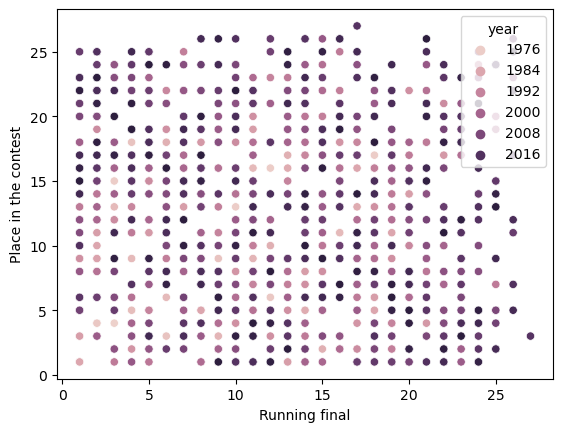

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=contestants_c, x='running_final', y='place_contest', hue='year')
plt.xlabel('Running final')
plt.ylabel('Place in the contest')

4. Since countries are not able to vote for themselves, it was suspected for many years that countries which were close to each other or had friendly relationships tend to vote amongs them and as a gesture of reciprocity the heped countries would do the same. So now we wnat to check if there was actually voting for "blocs".

To perform the following analysis we will use the "votes" data set and we will filter the data up 2015.

In [26]:
votes6 = votes2[(votes2['total_points']>=8) & (votes2['year']>=1975) & (votes2['year']<=2015)]
votes6

,year,round,from_country_id,to_country_id,from_country,to_country,total_points,tele_points,jury_points
4367,1975,final,be,gb,be,gb,10,NaN,NaN
4371,1975,final,be,ch,be,ch,8,NaN,NaN
4374,1975,final,be,ie,be,ie,12,NaN,NaN
4385,1975,final,fi,nl,fi,nl,10,NaN,NaN
4387,1975,final,fi,it,fi,it,12,NaN,NaN
...,...,...,...,...,...,...,...,...,...
38886,2015,final,ch,au,ch,au,8,NaN,NaN
38889,2015,final,ch,no,ch,no,10,NaN,NaN
38909,2015,final,gb,se,gb,se,12,NaN,NaN
38911,2015,final,gb,it,gb,it,8,NaN,NaN


In [27]:
voting = votes6.groupby(['from_country','to_country'])['total_points'].sum()
pd.DataFrame(voting)

total_points
from_country to_country              
ad           es                    60
             fi                    10
             fr                     8
             gr                    16
             il                     8
...                               ...
yu           mt                    10
             nl                    16
             no                    10
             se                    12
             tr                    22

[1124 rows x 1 columns]

In [28]:
voting.unstack('to_country')

to_country,al,am,at,au,az,ba,be,bg,by,ch,...,pt,ro,rs,ru,se,si,sk,tr,ua,yu
from_country,,,,,,,,,,,,,,,,,,,,,
ad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,10.0,NaN,NaN,8.0,NaN,NaN,NaN,22.0,NaN
al,NaN,NaN,NaN,NaN,8.0,30.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.0,10.0,NaN,NaN,64.0,8.0,NaN
am,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,...,NaN,NaN,NaN,88.0,NaN,NaN,NaN,NaN,42.0,NaN
at,8.0,12.0,NaN,12.0,20.0,42.0,NaN,NaN,NaN,58.0,...,NaN,8.0,22.0,16.0,90.0,NaN,NaN,30.0,NaN,18.0
au,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,10.0,12.0,NaN,NaN,NaN,NaN,NaN
az,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,42.0,NaN,NaN,NaN,48.0,64.0,NaN
ba,NaN,NaN,12.0,NaN,8.0,NaN,10.0,NaN,NaN,NaN,...,NaN,NaN,56.0,NaN,32.0,30.0,NaN,70.0,NaN,NaN
be,10.0,34.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,60.0,...,NaN,10.0,NaN,18.0,64.0,NaN,NaN,68.0,8.0,30.0
bg,NaN,40.0,NaN,NaN,42.0,NaN,NaN,NaN,NaN,NaN,...,NaN,8.0,12.0,10.0,8.0,NaN,NaN,20.0,18.0,NaN


In [29]:
pd.crosstab(votes6['from_country'], votes6['to_country'])

to_country,al,am,at,au,az,ba,be,bg,by,ch,...,pt,ro,rs,ru,se,si,sk,tr,ua,yu
from_country,,,,,,,,,,,,,,,,,,,,,
ad,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,2,0
al,0,0,0,0,1,3,0,0,0,0,...,0,0,0,1,1,0,0,7,1,0
am,0,0,0,0,0,0,0,0,2,0,...,0,0,0,8,0,0,0,0,4,0
at,1,1,0,1,2,4,0,0,0,6,...,0,1,2,2,9,0,0,3,0,2
au,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
az,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,4,6,0
ba,0,0,1,0,1,0,1,0,0,0,...,0,0,5,0,3,3,0,7,0,0
be,1,3,4,0,0,0,0,0,0,6,...,0,1,0,2,6,0,0,6,1,3
bg,0,5,0,0,4,0,0,0,0,0,...,0,1,1,1,1,0,0,2,2,0


With the last two tables we can see how there seems to be some preference of some coutries over others, but because of the size of the table the data appears to be somewhat "noisy", to make this analysis easier for us, we are going to use a table showing the most relevant data and look if there is any pattern.

In [30]:
voting2 = voting.reset_index(['from_country','to_country'])
voting2 = voting2[voting2['total_points']>=100]
voting2

,from_country,to_country,total_points
17,al,gr,110
43,at,gb,122
46,at,ie,104
107,be,gb,102
149,by,ru,124
201,cy,gr,288
234,de,gb,104
251,de,se,112
252,de,tr,156
277,dk,se,218


Text(0, 0.5, 'To country')

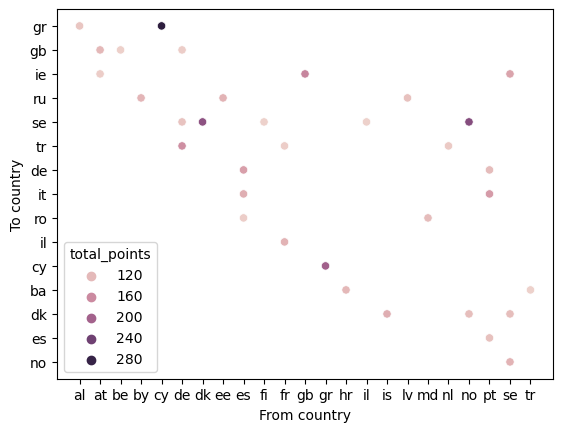

In [31]:
sns.scatterplot(data=voting2, x='from_country', y='to_country', hue='total_points')
plt.xlabel('From country')
plt.ylabel('To country')

With the past table we conclude our analysis of the voting for blocs hypothesis.

5. Due to the concerns from the public about some countries teaming up for voting purposes since the year 2016 anew system was implemented. In which the voting was going to be held not only by the public, but also by a team of judges from each country to ensure impartiality.

During this las part we will analyse and compare the data since the year 2016 and determine if this make a difference to the results compared with previous years.

In [32]:
votes7 = votes2[(votes2['total_points']>=8) & (votes2['year']>=2016)]
votes7

,year,round,from_country_id,to_country_id,from_country,to_country,total_points,tele_points,jury_points
39614,2016,final,al,au,al,au,24,12.0,12.0
39615,2016,final,al,ru,al,ru,14,7.0,7.0
39616,2016,final,al,bg,al,bg,12,8.0,4.0
39618,2016,final,al,fr,al,fr,10,0.0,10.0
39628,2016,final,al,it,al,it,18,10.0,8.0
...,...,...,...,...,...,...,...,...,...
51312,2023,final,gb,lt,gb,lt,18,10.0,8.0
51320,2023,final,gb,pl,gb,pl,8,8.0,0.0
51329,2023,final,wld,fi,wld,fi,10,10.0,NaN
51330,2023,final,wld,il,wld,il,12,12.0,NaN


In [33]:
voting3 = votes7.groupby(['from_country','to_country'])[['tele_points','jury_points']].sum()
pd.DataFrame(voting3)

tele_points  jury_points
from_country to_country                          
al           am                  0.0         10.0
             au                 12.0         12.0
             az                  3.0          8.0
             bg                 24.0         22.0
             ch                 16.0         22.0
...                              ...          ...
ua           ru                 12.0          0.0
             se                  3.0         12.0
wld          am                  8.0          0.0
             fi                 10.0          0.0
             il                 12.0          0.0

[1030 rows x 2 columns]

In [34]:
voting3.unstack('to_country')

tele_points                                                       \
to_country            al    am    at    au    az    be    bg   by    ch    cy   
from_country                                                                    
al                   NaN   0.0   NaN  12.0   3.0   NaN  24.0  NaN  16.0  19.0   
am                   NaN   NaN   NaN   NaN   NaN   NaN   NaN  NaN   8.0  38.0   
at                   2.0   NaN   NaN   3.0   NaN   8.0   7.0  NaN  17.0   NaN   
au                   NaN   NaN   7.0   NaN   NaN  15.0  15.0  NaN   5.0   8.0   
az                   0.0   NaN   NaN   2.0   NaN   NaN  20.0  0.0   8.0  10.0   
ba                   NaN   NaN   NaN   3.0   8.0   NaN   NaN  NaN   NaN   NaN   
be                   NaN   NaN   6.0   8.0   NaN   NaN  13.0  NaN   9.0   7.0   
bg                   NaN  13.0   4.0   5.0   NaN   0.0   NaN  NaN   NaN  12.0   
by                   NaN   7.0   0.0   NaN  14.0   NaN  12.0  NaN   4.0   3.0   
ch                  22.0   NaN  14.0   1.0   NaN   7.0   6.0  NaN   NaN   3.0   
cy                   NaN  12.0   0.0   5.0   0.0   NaN  41.0  NaN   7.0   NaN   
cz                   NaN  10.0   NaN   8.0  17.0   NaN  12.0  NaN   3.0   8.0   
de                   8.0   NaN   5.0  10.0   NaN  10.0   5.0  NaN  12.0   6.0   
dk                   NaN   NaN  10.0  14.0   5.0  20.0  10.0  NaN  12.0   NaN   
ee                   NaN   NaN   6.0  10.0   NaN  12.0   7.0  NaN   6.0   4.0   
es                   NaN   6.0   0.0   9.0   1.0   4.0  30.0  NaN  17.0   8.0   
fi                   NaN   NaN   9.0  21.0   NaN  10.0   7.0  NaN   8.0   NaN   
fr                   NaN  29.0   8.0   6.0   NaN   8.0   9.0  NaN   6.0   NaN   
gb                   NaN   NaN   0.0  18.0   3.0   9.0  34.0  NaN   8.0  10.0   
ge                   NaN  44.0   1.0   1.0  22.0   0.0   7.0  NaN   0.0  22.0   
gr                  15.0  10.0   NaN   5.0   0.0   0.0  10.0  NaN   NaN  72.0   
hr                   NaN   NaN   NaN   5.0   NaN   NaN   9.0  NaN  11.0   8.0   
hu                   0.0   NaN   3.0   3.0   NaN   8.0  12.0  0.0   5.0   NaN   
ie                   NaN   NaN   NaN  10.0   NaN   8.0  11.0  NaN  10.0   5.0   
il                   NaN   6.0   1.0  11.0   3.0   6.0  17.0  NaN  13.0   NaN   
is                   0.0   NaN   5.0  21.0   NaN  16.0   4.0  NaN  13.0   NaN   
it                  34.0   0.0   NaN   6.0   1.0   2.0   8.0  NaN   NaN   5.0   
lt                   NaN   NaN   3.0   5.0   5.0  12.0   7.0  NaN   6.0   NaN   
lv                   NaN   NaN   NaN   6.0   4.0  12.0   7.0  6.0   4.0   NaN   
md                   NaN   7.0   NaN   5.0  28.0   NaN  11.0  NaN   NaN   7.0   
me                  17.0   0.0   NaN   NaN   NaN   4.0   6.0  NaN   NaN   NaN   
mk                  34.0   NaN   NaN   3.0   NaN   4.0  22.0  NaN   7.0  14.0   
mt                   0.0   NaN   NaN  18.0   2.0   NaN  25.0  NaN   8.0  10.0   
nl                   NaN   8.0   9.0   5.0   NaN  36.0   8.0  NaN  13.0   5.0   
no                   NaN   NaN   8.0   8.0   3.0   NaN  13.0  NaN   8.0   2.0   
pl                   NaN   NaN   0.0  13.0   NaN  12.0   8.0  NaN   7.0  12.0   
pt                   0.0   NaN   0.0   4.0   0.0  10.0   8.0  NaN   6.0   NaN   
ro                   NaN   NaN   0.0   2.0   6.0   NaN   8.0  NaN  15.0   7.0   
rs                   NaN   NaN   3.0   6.0   0.0   0.0  18.0  NaN   6.0  10.0   
ru                   NaN  12.0   8.0   NaN  22.0   NaN   NaN  8.0   NaN  23.0   
se                   NaN   NaN   2.0  17.0   3.0  12.0   7.0  NaN  14.0   4.0   
si                   NaN   NaN   2.0   3.0   0.0   6.0   9.0  NaN   9.0   6.0   
sm                   NaN   NaN   NaN   NaN   4.0   5.0  12.0  NaN   NaN  15.0   
ua                   NaN   NaN   NaN   4.0  10.0   0.0   NaN  8.0   7.0   NaN   
wld                  NaN   8.0   NaN   NaN   NaN   NaN   NaN  NaN   NaN   NaN   

              ... jury_points                                                  \
to_country    ...          no    pl    pt  

In [35]:
voting4 = voting3.reset_index(['from_country','to_country'])
voting4 = voting4[voting4['tele_points']>=40]
voting4


,from_country,to_country,tele_points,jury_points
14,al,it,72.0,55.0
58,at,it,42.0,31.0
107,az,il,42.0,16.0
117,az,ua,45.0,30.0
139,be,nl,54.0,20.0
204,ch,it,65.0,27.0
210,ch,rs,48.0,0.0
217,cy,bg,41.0,12.0
224,cy,gr,46.0,48.0
262,cz,ua,58.0,16.0


In [36]:
import scipy.stats
scipy.stats.mannwhitneyu(voting4['tele_points'], voting4['jury_points'])

MannwhitneyuResult(statistic=1529.0, pvalue=7.0673209401946625e-09)